# 🛡️ FakeShield — Fake News Verification System
## Notebook: CSV Exploration + Sentence Transformer Similarity Engine

**Approach:** No labeled data, no supervised ML.  
We use **Sentence Transformers (BERT-based)** to encode text into vectors and compute **cosine similarity** against trusted news articles.

---

## Step 1: Install Required Libraries

In [1]:
# Run this cell only once to install dependencies
import sys
!{sys.executable} -m pip install sentence-transformers pandas scikit-learn numpy --quiet

'c:\New' is not recognized as an internal or external command,
operable program or batch file.


## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('✅ All libraries imported successfully!')

c:\New folder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!


## Step 3: Load and Explore the CSV Dataset

In [3]:
# Load the trusted news CSV dataset
df = pd.read_csv('data/trusted_news.csv')

print(f'Total articles loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
print()
df.head(10)

Total articles loaded: 60
Columns: ['source', 'headline', 'description', 'url', 'reliability']



,source,headline,description,url,reliability
0,TOI,India's GDP grows at 7.2% in Q3 2024,India's economy expanded by 7.2% in the third ...,https://timesofindia.com/article1,0.9
1,TOI,PM Modi launches new infrastructure initiative...,Prime Minister Narendra Modi inaugurated a maj...,https://timesofindia.com/article2,0.9
2,TOI,RBI keeps repo rate unchanged at 6.5% in lates...,The Reserve Bank of India maintained the bench...,https://timesofindia.com/article3,0.9
3,TOI,India beats Pakistan in ICC Champions Trophy f...,Team India secured a dominant victory over Pak...,https://timesofindia.com/article4,0.9
4,TOI,ISRO successfully launches PSLV-C58 mission wi...,Indian Space Research Organisation achieved an...,https://timesofindia.com/article5,0.9
5,TOI,Supreme Court upholds validity of new citizens...,The Supreme Court of India in a landmark judgm...,https://timesofindia.com/article6,0.9
6,TOI,Delhi records worst air quality of the year AQ...,New Delhi's air quality plunged to severe leve...,https://timesofindia.com/article7,0.9
7,TOI,India launches UPI payment system in 10 new co...,India's Unified Payments Interface has been ex...,https://timesofindia.com/article8,0.9
8,TOI,Mumbai local train services disrupted due to h...,Heavy rainfall lashed Mumbai causing waterlogg...,https://timesofindia.com/article9,0.9
9,TOI,Government announces free electricity up to 30...,The central government rolled out the PM Surya...,https://timesofindia.com/article10,0.9


In [4]:
# Source distribution
print('📊 Articles per source:')
print(df['source'].value_counts())

print()
print('📊 Reliability weights per source:')
print(df.groupby('source')['reliability'].first())

📊 Articles per source:
source
TOI        20
HT         20
Tribune    20
Name: count, dtype: int64

📊 Reliability weights per source:
source
HT         0.85
TOI        0.90
Tribune    0.80
Name: reliability, dtype: float64


In [5]:
# Preview all headlines as a neat table
print('📰 All Trusted Headlines:\n')
for i, row in df.iterrows():
    print(f"[{row['source']}] {row['headline']}")

📰 All Trusted Headlines:

[TOI] India's GDP grows at 7.2% in Q3 2024
[TOI] PM Modi launches new infrastructure initiative worth Rs 10 lakh crore
[TOI] RBI keeps repo rate unchanged at 6.5% in latest monetary policy review
[TOI] India beats Pakistan in ICC Champions Trophy final by 6 wickets
[TOI] ISRO successfully launches PSLV-C58 mission with Earth observation satellite
[TOI] Supreme Court upholds validity of new citizenship amendment rules
[TOI] Delhi records worst air quality of the year AQI crosses 450
[TOI] India launches UPI payment system in 10 new countries
[TOI] Mumbai local train services disrupted due to heavy monsoon rains
[TOI] Government announces free electricity up to 300 units under PM Surya Ghar scheme
[TOI] India becomes world's third largest economy surpassing Japan
[TOI] New education policy NEP 2020 fully implemented across all states
[TOI] Chandrayaan-4 mission to be launched in 2026 says ISRO chief
[TOI] India signs free trade agreement with European Union
[TOI

## Step 4: Load the Sentence Transformer Model

We use **`all-MiniLM-L6-v2`** — a lightweight BERT-based model.  
- Produces **384-dimensional** dense embeddings  
- Understands **semantic meaning** (not just keywords)  
- Downloaded once (~90MB), cached locally after that

In [6]:
print('⏳ Loading model: all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ Model loaded!')
print(f'Embedding dimension: {model.get_sentence_embedding_dimension()}')

⏳ Loading model: all-MiniLM-L6-v2 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5718.47it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded!
Embedding dimension: 384


C:\Users\riddh\AppData\Local\Temp\ipykernel_14124\3314207446.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'Embedding dimension: {model.get_sentence_embedding_dimension()}')


## Step 5: Encode All Articles into Embeddings

We combine `headline + description` for each article to get a richer representation.

In [7]:
# Combine headline + description for richer semantic representation
df['combined_text'] = df['headline'] + '. ' + df['description']

print('⏳ Encoding all trusted articles...')
article_embeddings = model.encode(
    df['combined_text'].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print(f'\n✅ Encoded {len(article_embeddings)} articles')
print(f'Embedding shape: {article_embeddings.shape}')  # (60, 384)

⏳ Encoding all trusted articles...


Batches: 100%|██████████| 2/2 [00:00<00:00,  5.10it/s]


✅ Encoded 60 articles
Embedding shape: (60, 384)


## Step 6: Core Similarity Function

Cosine Similarity formula:

$$\text{similarity} = \frac{\vec{A} \cdot \vec{B}}{|\vec{A}| \times |\vec{B}|}$$

Range: 0.0 (completely different) → 1.0 (identical meaning)

In [8]:
def verify_news(user_news: str, top_k: int = 3) -> dict:
    """
    Verify whether a news text is Real, Suspicious, or Fake.
    
    Args:
        user_news: The news headline/article to verify
        top_k:     How many top matches to return
    
    Returns:
        Dictionary with prediction, confidence, and matched articles
    """
    # Encode user input
    user_embedding = model.encode([user_news], convert_to_numpy=True)
    
    # Compute cosine similarity against all articles
    scores = cosine_similarity(user_embedding, article_embeddings)[0]
    
    # Get top-k article indices
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    # Best match drives the verdict
    best_score  = float(scores[top_indices[0]])
    best_source = df.iloc[top_indices[0]]['source']
    reliability = df.iloc[top_indices[0]]['reliability']
    
    # --- Decision Logic (NO labels) ---
    if best_score >= 0.85:
        prediction = 'Real ✅'
    elif best_score >= 0.60:
        prediction = 'Suspicious ⚠️'
    else:
        prediction = 'Fake ❌'
    
    # Confidence = similarity × source reliability
    confidence = best_score * reliability
    
    # Collect matched articles
    matches = []
    for i in top_indices:
        matches.append({
            'source':     df.iloc[i]['source'],
            'headline':   df.iloc[i]['headline'],
            'similarity': round(float(scores[i]), 4)
        })
    
    return {
        'prediction':  prediction,
        'confidence':  round(confidence, 4),
        'similarity':  round(best_score, 4),
        'matches':     matches
    }

print('✅ verify_news() function ready!')

✅ verify_news() function ready!


## Step 7: Test with Sample News

In [9]:
# Test 1: REAL news (similar to CSV article)
real_news = "India's GDP grows at 7.2% in Q3 2024"
result = verify_news(real_news)

print(f'📰 Input: "{real_news}"')
print(f'🔍 Verdict:    {result["prediction"]}')
print(f'📊 Similarity: {result["similarity"]*100:.1f}%')
print(f'💯 Confidence: {result["confidence"]*100:.1f}%')
print(f'\n🏆 Top Matches:')
for i, m in enumerate(result['matches'], 1):
    print(f'  {i}. [{m["source"]}] {m["headline"]} — {m["similarity"]*100:.1f}%')

📰 Input: "India's GDP grows at 7.2% in Q3 2024"
🔍 Verdict:    Real ✅
📊 Similarity: 92.7%
💯 Confidence: 83.4%

🏆 Top Matches:
  1. [TOI] India's GDP grows at 7.2% in Q3 2024 — 92.7%
  2. [TOI] India becomes world's third largest economy surpassing Japan — 65.9%
  3. [HT] India's exports grow 12% in November crossing 40 billion dollars — 60.6%


In [10]:
# Test 2: FAKE news (random fabrication)
fake_news = "Aliens landed on Parliament in New Delhi and declared India a UFO zone"
result = verify_news(fake_news)

print(f'📰 Input: "{fake_news}"')
print(f'🔍 Verdict:    {result["prediction"]}')
print(f'📊 Similarity: {result["similarity"]*100:.1f}%')
print(f'💯 Confidence: {result["confidence"]*100:.1f}%')
print(f'\n🏆 Top Matches (closest, still irrelevant):')
for i, m in enumerate(result['matches'], 1):
    print(f'  {i}. [{m["source"]}] {m["headline"]} — {m["similarity"]*100:.1f}%')

📰 Input: "Aliens landed on Parliament in New Delhi and declared India a UFO zone"
🔍 Verdict:    Fake ❌
📊 Similarity: 35.7%
💯 Confidence: 32.1%

🏆 Top Matches (closest, still irrelevant):
  1. [TOI] Delhi records worst air quality of the year AQI crosses 450 — 35.7%
  2. [HT] Kejriwal announces Rs 2100 monthly allowance for Delhi women — 31.6%
  3. [Tribune] Ludhiana Smart City project upgrade traffic lights with AI sensors — 28.0%


In [11]:
# Test 3: SUSPICIOUS news (paraphrased but not exact)
suspicious_news = "India's economy showed some improvement in the last quarter of 2024"
result = verify_news(suspicious_news)

print(f'📰 Input: "{suspicious_news}"')
print(f'🔍 Verdict:    {result["prediction"]}')
print(f'📊 Similarity: {result["similarity"]*100:.1f}%')
print(f'💯 Confidence: {result["confidence"]*100:.1f}%')
print(f'\n🏆 Top Matches:')
for i, m in enumerate(result['matches'], 1):
    print(f'  {i}. [{m["source"]}] {m["headline"]} — {m["similarity"]*100:.1f}%')

📰 Input: "India's economy showed some improvement in the last quarter of 2024"
🔍 Verdict:    Suspicious ⚠️
📊 Similarity: 73.4%
💯 Confidence: 66.0%

🏆 Top Matches:
  1. [TOI] India's GDP grows at 7.2% in Q3 2024 — 73.4%
  2. [TOI] India becomes world's third largest economy surpassing Japan — 60.0%
  3. [HT] India's inflation falls to 4.1% lowest in 18 months — 52.8%


## Step 8: Batch Test — All Three Cases at Once

In [12]:
# Run multiple test cases and display a results table
test_cases = [
    "India beats Pakistan in ICC Champions Trophy final by 6 wickets",
    "ISRO successfully launches a new satellite",
    "PM Modi announces free electricity for everyone in India starting tomorrow",
    "Aliens attack Mumbai",
    "Delhi air quality index crosses 450 due to pollution",
    "India signs trade deal with Europe",
    "Government gives free gold to all citizens next week",
    "Punjab farmers protest land acquisition",
]

print(f'{"News Text":<60} {"Verdict":<18} {"Similarity":>12} {"Confidence":>12}')
print('-' * 106)

for news in test_cases:
    r = verify_news(news)
    short = news[:57] + '...' if len(news) > 57 else news
    print(f'{short:<60} {r["prediction"]:<18} {r["similarity"]*100:>10.1f}%  {r["confidence"]*100:>10.1f}%')

News Text                                                    Verdict              Similarity   Confidence
----------------------------------------------------------------------------------------------------------
India beats Pakistan in ICC Champions Trophy final by 6 w... Real ✅                   94.0%        84.6%
ISRO successfully launches a new satellite                   Suspicious ⚠️            63.7%        57.3%
PM Modi announces free electricity for everyone in India ... Fake ❌                   56.1%        50.5%
Aliens attack Mumbai                                         Fake ❌                   32.7%        29.5%
Delhi air quality index crosses 450 due to pollution         Suspicious ⚠️            82.8%        74.5%
India signs trade deal with Europe                           Suspicious ⚠️            81.9%        73.7%
Government gives free gold to all citizens next week         Fake ❌                   31.6%        28.4%
Punjab farmers protest land acquisition             

## Step 9: Visualise Similarity Scores (Bar Chart)

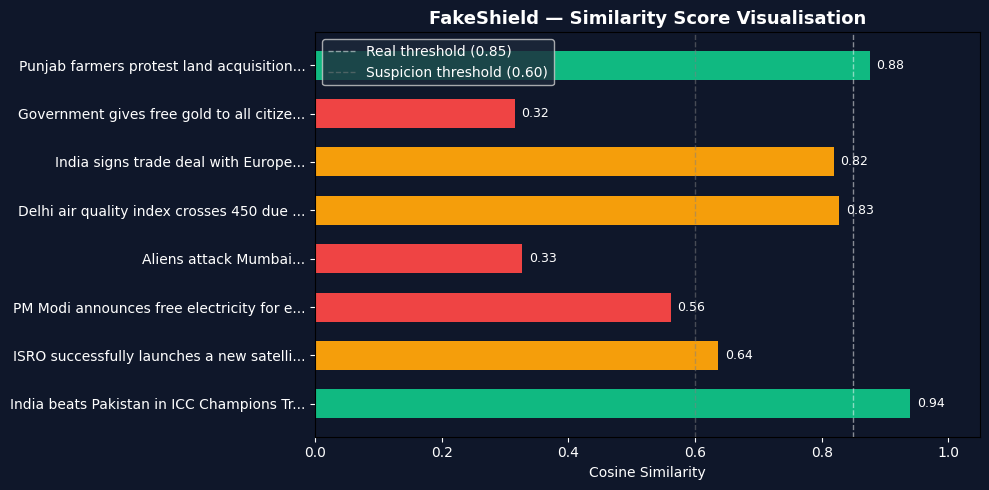


✅ Chart saved to data/similarity_chart.png


In [14]:
import matplotlib.pyplot as plt

labels = [news[:40] + '...' for news in test_cases]
sims   = []
colors = []

for news in test_cases:
    r = verify_news(news)
    sims.append(r['similarity'])
    if r['similarity'] >= 0.85:
        colors.append('#10b981')   # green
    elif r['similarity'] >= 0.60:
        colors.append('#f59e0b')   # yellow
    else:
        colors.append('#ef4444')   # red

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#0f172a')
fig.patch.set_facecolor('#0f172a')

bars = ax.barh(labels, sims, color=colors, height=0.6)

# Threshold lines
ax.axvline(x=0.85, color='white', linestyle='--', linewidth=1, alpha=0.5, label='Real threshold (0.85)')
ax.axvline(x=0.60, color='gray',  linestyle='--', linewidth=1, alpha=0.5, label='Suspicion threshold (0.60)')

# Labels on bars
for bar, val in zip(bars, sims):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', color='white', fontsize=9)

ax.set_xlabel('Cosine Similarity', color='white')
ax.set_title('FakeShield — Similarity Score Visualisation', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.set_xlim(0, 1.05)
ax.legend(facecolor='#1e293b', labelcolor='white')
plt.tight_layout()
plt.savefig('data/similarity_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Chart saved to data/similarity_chart.png')

## Step 10: Summary

| Component | Detail |
|-----------|--------|
| Model | `all-MiniLM-L6-v2` (BERT-based) |
| Embedding Dim | 384 |
| Dataset | 60 trusted articles (TOI, HT, Tribune) |
| Similarity | Cosine Similarity |
| Real threshold | > 0.85 |
| Suspicious | 0.60 – 0.85 |
| Fake | < 0.60 |
| Confidence | similarity × source reliability |


**No training. No labels. Pure semantic comparison.** 🛡️